# Complete Machine Learning Pipeline for Disease Prediction
Dataset: Pima Indians Diabetes Dataset

This notebook follows the assignment steps exactly:
1. Dataset Preparation
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Scaling
5. Machine Learning Model (LSVM)
6. Model Evaluation
7. Model Comparison
8. Visualization
9. Interpretation


## Import Required Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Part 1 – Dataset Preparation

### 1. Download and Load Dataset

In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2. Display Dataset Information

In [8]:
print('Dataset Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)

print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Part 2 – Exploratory Data Analysis (EDA)

### Summary Statistics

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Check Missing Values

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Class Distribution of Target Variable

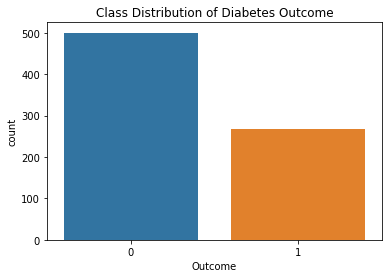

In [11]:
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution of Diabetes Outcome')
plt.show()

### Correlation Heatmap Between Features

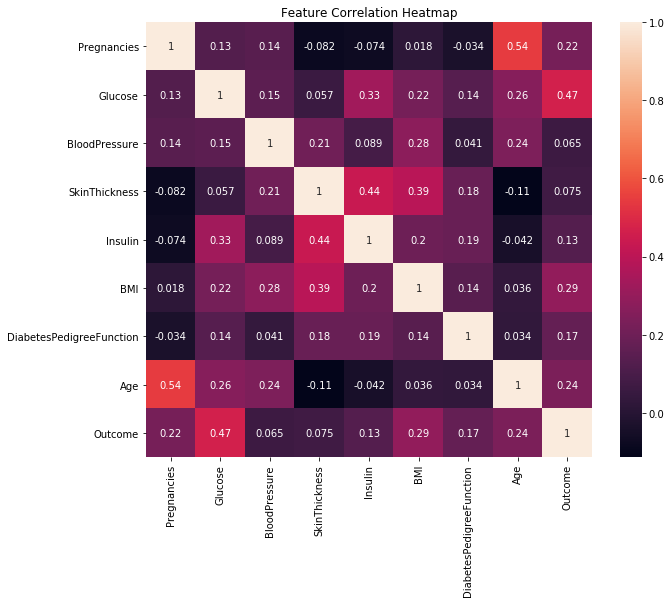

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# Part 3 – Data Preprocessing

### Separate Features (X) and Target Variable (y)

In [14]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

### Split Dataset into Training and Testing Sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Part 4 – Feature Scaling

Standardization is applied because algorithms like Support Vector Machines rely on distance calculations. Scaling ensures that all features contribute equally to the model.

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Part 5 – Machine Learning Model (Linear SVM)

In [22]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

# Part 6 – Model Evaluation

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

print('\nConfusion Matrix:')
print(cm)

Accuracy: 0.7597402597402597
Precision: 0.6666666666666666
Recall: 0.6545454545454545
F1 Score: 0.6605504587155963

Confusion Matrix:
[[81 18]
 [19 36]]


# Part 7 – Model Comparison (Advanced)

### Logistic Regression

In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print('Logistic Regression Accuracy:', lr_acc)

Logistic Regression Accuracy: 0.7532467532467533


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


### Random Forest

In [25]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', rf_acc)

Random Forest Accuracy: 0.7272727272727273


/opt/conda/lib/python3.6/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


### Accuracy Comparison Table

In [26]:
results = pd.DataFrame({
    'Model': ['Linear SVM', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, lr_acc, rf_acc]
})

results

,Model,Accuracy
0,Linear SVM,0.759740
1,Logistic Regression,0.753247
2,Random Forest,0.727273


# Part 8 – Visualization

### Glucose Distribution by Diabetes Outcome

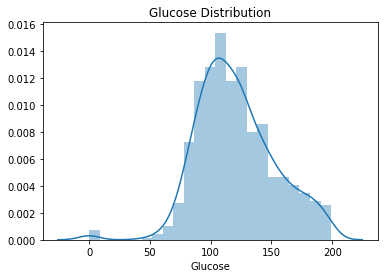

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.distplot(df['Glucose'])
plt.title('Glucose Distribution')
plt.show()

### Age Distribution

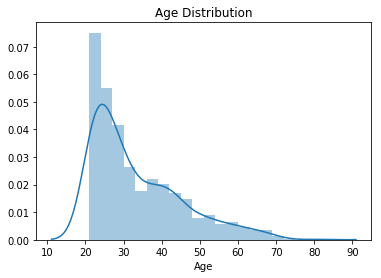

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.distplot(df['Age'], bins=20)
plt.title('Age Distribution')
plt.show()

### BMI Distribution

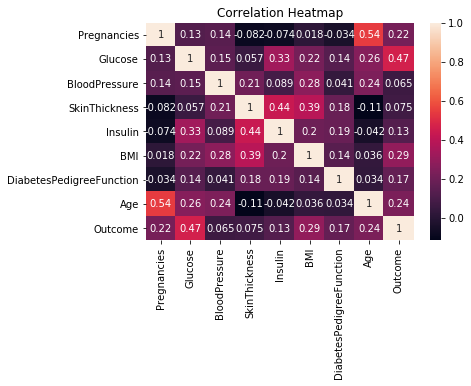

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

# Part 9 – Interpretation

**1. Which features correlate most with diabetes?**  
Glucose, BMI, and Age typically show stronger correlation with diabetes outcome.

**2. Which model performed best?**  
The model with the highest accuracy in the comparison table performs best.

**3. Why is scaling important for SVM?**  
SVM relies on distance calculations. Feature scaling ensures that all variables contribute equally.

**4. What limitations exist in this dataset?**  
- Small dataset size
- Limited medical features
- Data collected from a specific population
- Possible measurement errors
